In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# **LOAD DATA**

In [33]:
data = torch.load("/home/user-05/isaac_lab_projects/IsaacLab_fork/logs/rsl_rl/data_rollout/rollout_00000999.pt")
obs = data["obs"]
act = data["act"]
rew = data["rew"]
foot_rew_l = data["feet_rew_l"]
foot_rew_r = data["feet_rew_r"]
foot_frc_l = data["feet_frc_l"]
foot_frc_r = data["feet_frc_r"]
foot_spd_l = data["feet_spd_l"]
foot_spd_r = data["feet_spd_r"]
n_foot_frc_l = data["n_feet_frc_l"]
n_foot_frc_r = data["n_feet_frc_r"]
n_foot_spd_l = data["n_feet_spd_l"]
n_foot_spd_r = data["n_feet_spd_r"]
foot_pos_r = data["feet_pos_r"]
foot_pos_l = data["feet_pos_l"]

# **PLOTTING**
## **REWARD**
### TOT REWARD AND FEET REWARD OF A SELECTED ENV

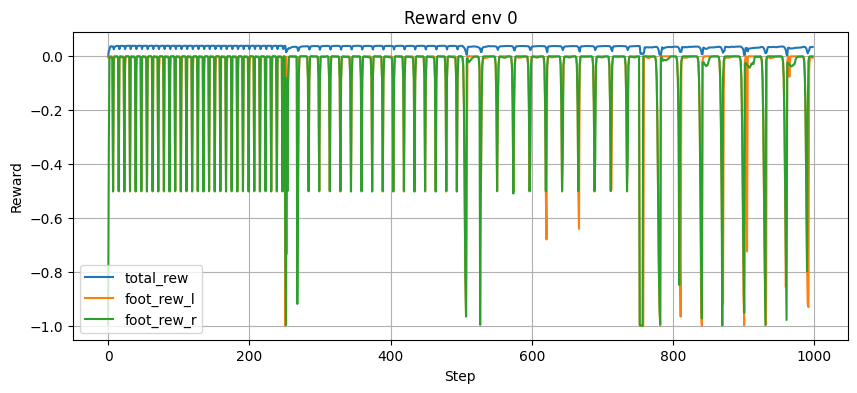

In [34]:
# select environment to plot
env_id = 0

plt.figure(figsize=(10,4))
plt.plot(rew[env_id], label="total_rew")
plt.plot(foot_rew_l[env_id], label="foot_rew_l")
plt.plot(foot_rew_r[env_id], label="foot_rew_r")
plt.legend()
plt.title(f"Reward env {env_id}")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

In [35]:
print("rew dimensions:", rew.shape)

rew dimensions: torch.Size([1, 999])


### REWARD MEAN AND STD (OR CI)

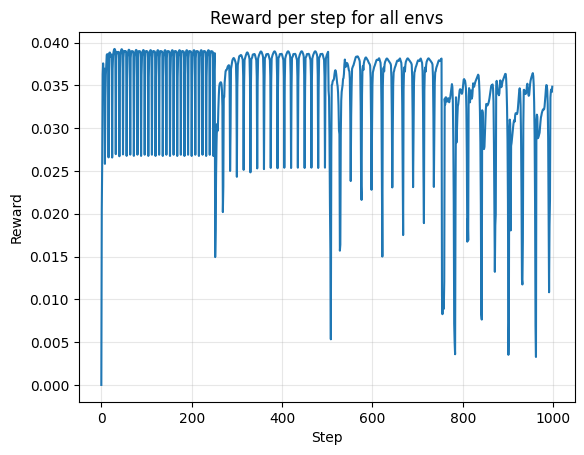

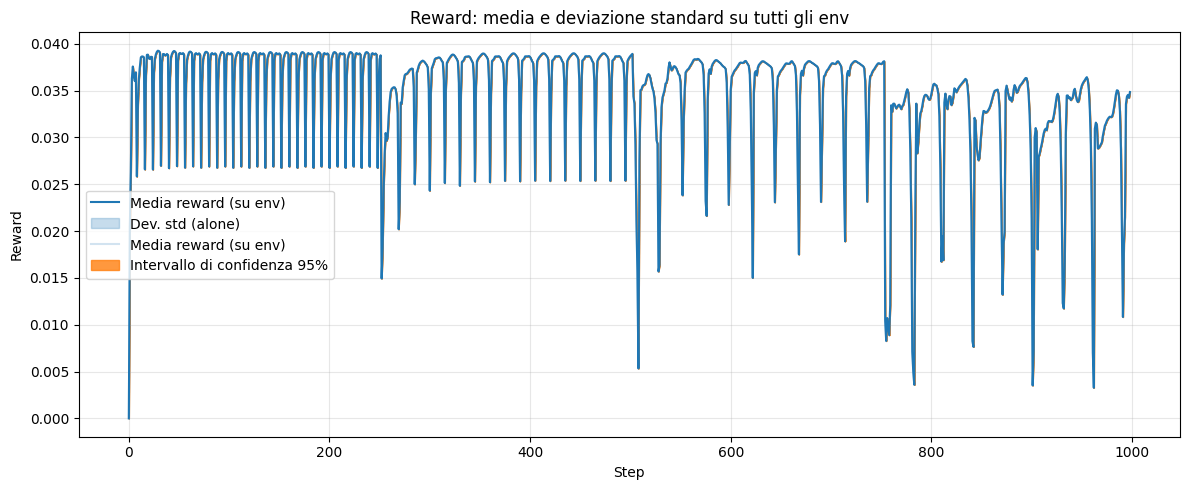

In [36]:
# Converti in numpy per comodità
rew_np = rew.cpu().numpy() if isinstance(rew, torch.Tensor) else np.array(rew)

for env_ids in range(rew_np.shape[0]):
    plt.plot(rew_np[env_ids])
plt.title("Reward per step for all envs")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True, alpha=0.3)
plt.show()

# Rendi la forma uniforme: (num_envs, num_steps)
if rew_np.ndim != 2:
    raise ValueError(f"rew ha forma inattesa: {rew_np.shape}")


num_envs, num_steps = rew_np.shape
steps = np.arange(num_steps)

# (Opzionale) Se hai NA/NaN, usa nanmean/nanstd
mean_rew = np.nanmean(rew_np, axis=0)       # media su env per ogni step
std_rew  = np.nanstd(rew_np, axis=0)        # std su env per ogni step
#intervallo di confidenza invece della deviazione standard,  1.96 * std / sqrt(num_envs) per un 95% CI
ci95 = 1.960 * std_rew / np.sqrt(num_envs)

# (Opzionale) smoothing con media mobile per migliorare leggibilità
def moving_average(x, window=25):
    if window is None or window <= 1:
        return x
    # padding riflessivo per non accorciare la serie
    pad = window // 2
    x_pad = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(x_pad, kernel, mode='valid')

smooth_window = 1 #25  # metti None o 1 se non vuoi smoothing
mean_s = moving_average(mean_rew, window=smooth_window)
std_s  = moving_average(std_rew,  window=smooth_window)

# Plot
plt.figure(figsize=(12, 5))
# MEAN e DEVIAZIONE STANDARD
plt.plot(steps, mean_s, color="C0", label="Media reward (su env)")
plt.fill_between(steps, mean_s - std_s, mean_s + std_s, color="C0", alpha=0.25,
                 label="Dev. std (alone)")
# INTERVALLO DI CONFIDENZA 
plt.plot(steps, mean_rew, color="C0", alpha=0.2,label="Media reward (su env)")
plt.fill_between(steps, mean_rew- ci95, mean_rew + ci95, color="C1", alpha=0.8,
                 label="Intervallo di confidenza 95%")
plt.title("Reward: media e deviazione standard su tutti gli env")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## **FOOT FORCES AND VELOCITIES (single env)**

### FORCES (NORMALIZED AND NOT)

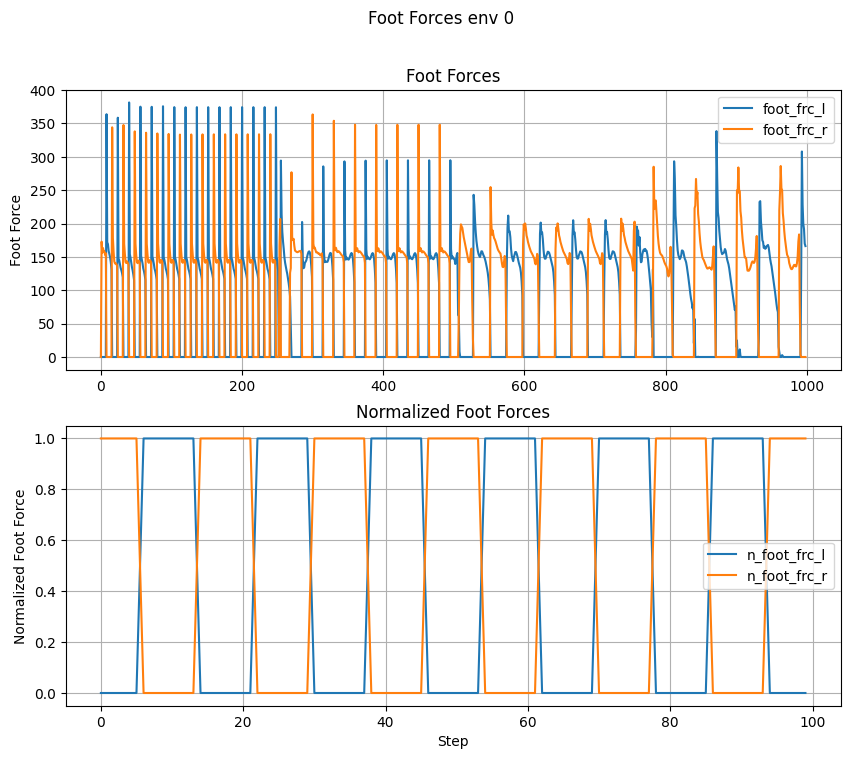

In [48]:
#2 subplots: foot forces an normalized foot forces
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(f"Foot Forces env {env_id}")   
ax1.plot(foot_frc_l[env_id, :], label="foot_frc_l")
ax1.plot(foot_frc_r[env_id, :], label="foot_frc_r")
ax1.set_ylabel("Foot Force")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Foot Forces")
ax2.plot(n_foot_frc_l[env_id, 50:150], label="n_foot_frc_l")
ax2.plot(n_foot_frc_r[env_id, 50:150], label="n_foot_frc_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Force")
ax2.legend()
ax2.grid(True)
ax2.set_title("Normalized Foot Forces")  
plt.show()

### VELOCITIES (NORMALIZED AND NOT)

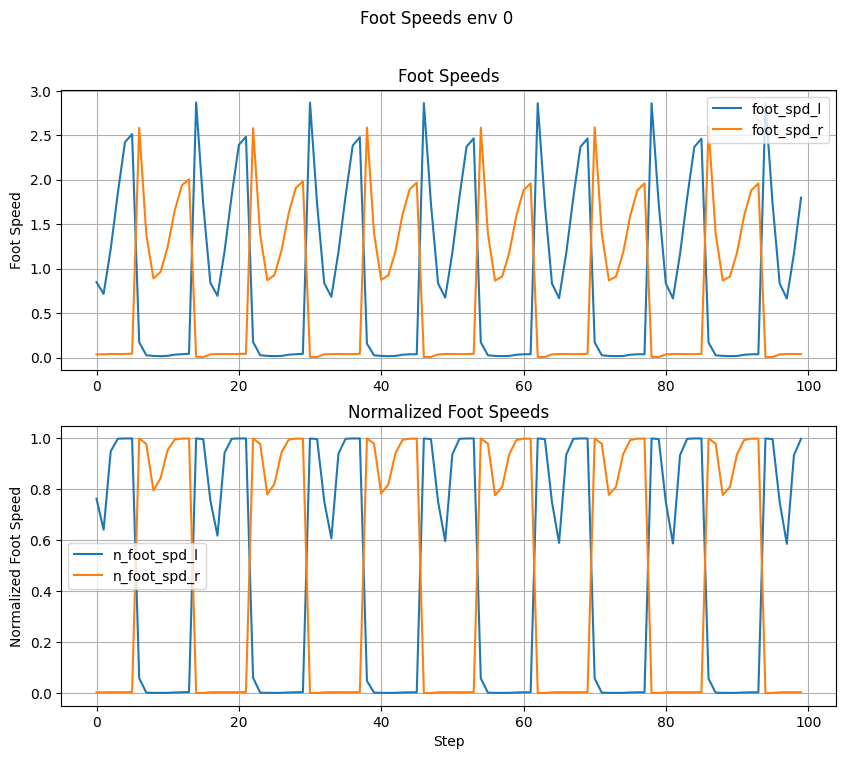

In [38]:
#2 subplots: foot speeds an normalized foot speeds
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(f"Foot Speeds env {env_id}")   
ax1.plot(foot_spd_l[env_id, 50:150], label="foot_spd_l")
ax1.plot(foot_spd_r[env_id, 50:150], label="foot_spd_r")
ax1.set_ylabel("Foot Speed")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Foot Speeds")
ax2.plot(n_foot_spd_l[env_id, 50:150], label="n_foot_spd_l")
ax2.plot(n_foot_spd_r[env_id, 50:150], label="n_foot_spd_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Speed")
ax2.legend()
ax2.grid(True)  
ax2.set_title("Normalized Foot Speeds")
plt.show()

### FOOT FORCES VS VELOCITIES (NORMALIZED AND NOT)

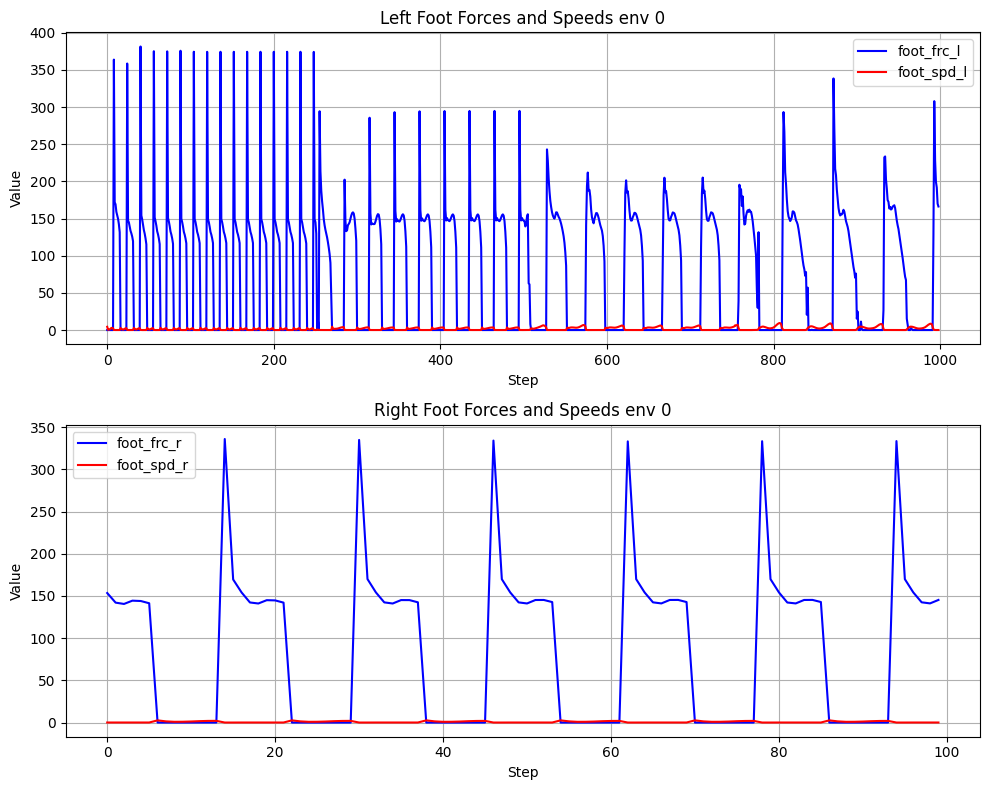

In [49]:
#2 subplots for left and right foot speed vs force
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(foot_frc_l[env_id, :], label="foot_frc_l", color='b')
axs[0].plot(foot_spd_l[env_id, :], label="foot_spd_l", color='r')
axs[0].set_title(f"Left Foot Forces and Speeds env {env_id}")
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Value")
axs[0].legend() 
axs[0].grid(True)
axs[1].plot(foot_frc_r[env_id, 50:150], label="foot_frc_r", color='b')
axs[1].plot(foot_spd_r[env_id, 50:150], label="foot_spd_r", color='r')
axs[1].set_title(f"Right Foot Forces and Speeds env {env_id}")
axs[1].set_xlabel("Step")   
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

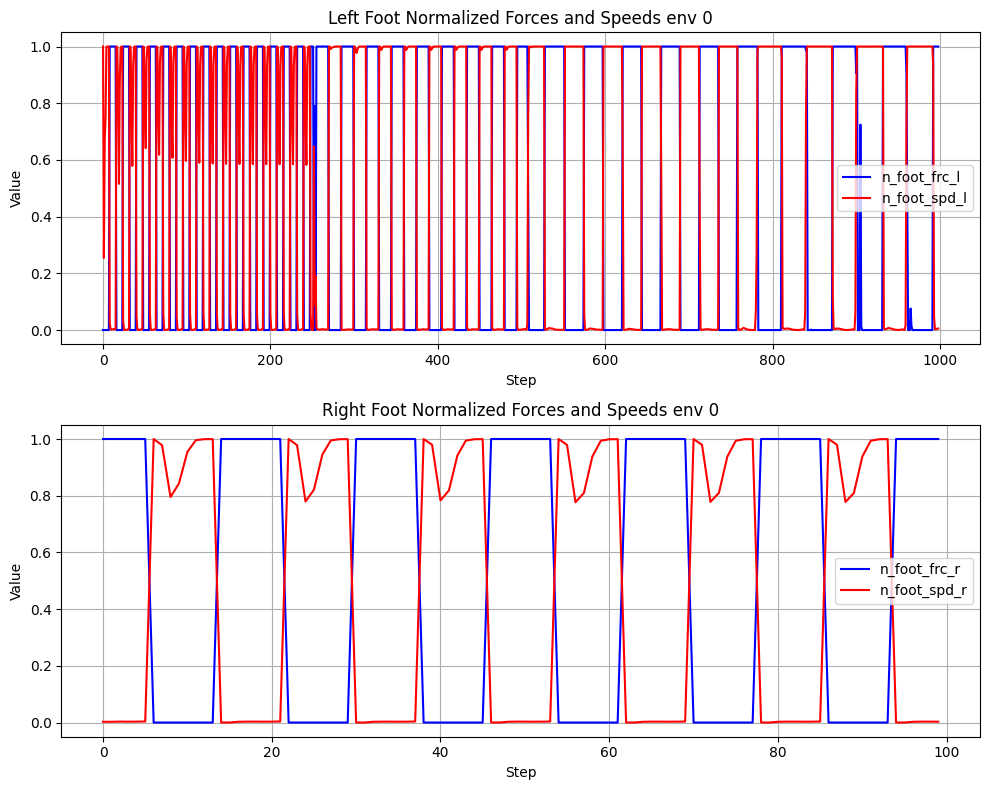

In [50]:
#2 subplots for left and right foot speed vs force (normalized)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(n_foot_frc_l[env_id, :], label="n_foot_frc_l", color='b')
axs[0].plot(n_foot_spd_l[env_id, :], label="n_foot_spd_l", color='r')
axs[0].set_title(f"Left Foot Normalized Forces and Speeds env {env_id}")
axs[0].set_xlabel("Step")       
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(n_foot_frc_r[env_id, 50:150], label="n_foot_frc_r", color='b')
axs[1].plot(n_foot_spd_r[env_id, 50:150], label="n_foot_spd_r", color='r')
axs[1].set_title(f"Right Foot Normalized Forces and Speeds env {env_id}")
axs[1].set_xlabel("Step")       
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()

## **FOOT FORCES AND VELOCITIES (all envs)**

### FORCES (NORMALIZED AND NOT)

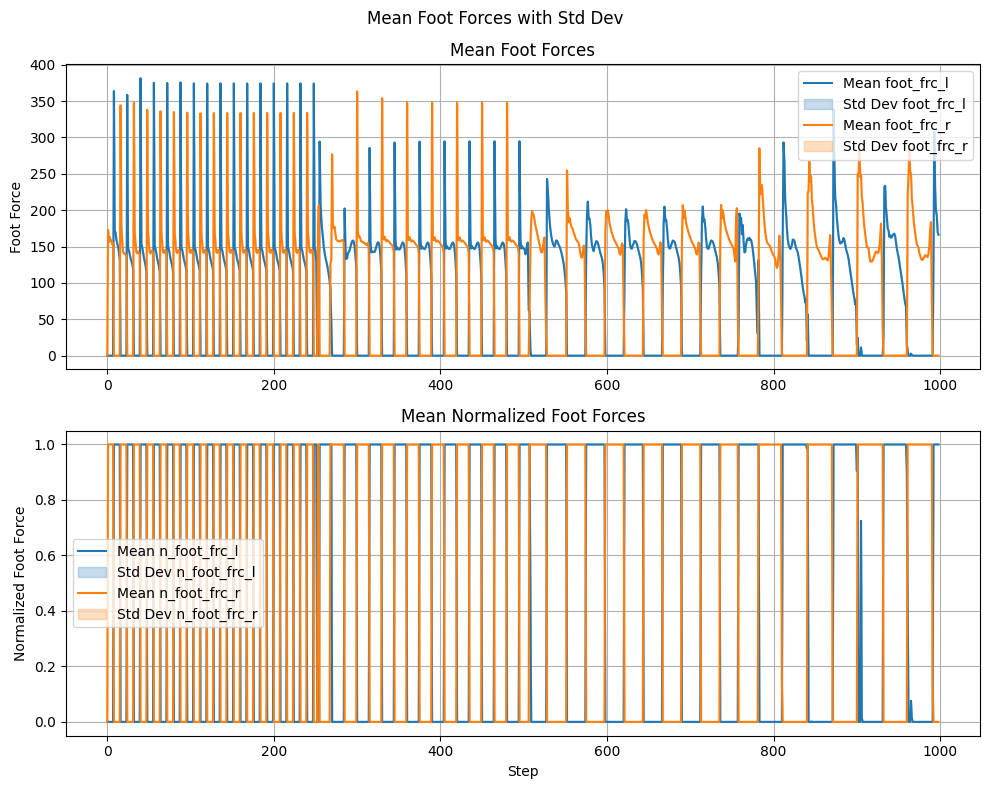

In [ ]:

mean_foot_frc_l = np.nanmean(foot_frc_l.cpu().numpy(), axis=0)
mean_foot_frc_r = np.nanmean(foot_frc_r.cpu().numpy(), axis=0)
mean_foot_n_frc_l = np.nanmean(n_foot_frc_l.cpu().numpy(), axis=0)
mean_foot_n_frc_r = np.nanmean(n_foot_frc_r.cpu().numpy(), axis=0)

std_foot_frc_l = np.nanstd(foot_frc_l.cpu().numpy(), axis=0)
std_foot_frc_r = np.nanstd(foot_frc_r.cpu().numpy(), axis=0)
std_foot_n_frc_l = np.nanstd(n_foot_frc_l.cpu().numpy(), axis=0)
std_foot_n_frc_r = np.nanstd(n_foot_frc_r.cpu().numpy(), axis=0)

# ci95_foot_frc_l = 1.960 * std_foot_frc_l / np.sqrt(num_envs)
# ci95_foot_frc_r = 1.960 * std_foot_frc_r / np.sqrt(num_envs)
# ci95_foot_n_frc_l = 1.960 * std_foot_n_frc_l / np.sqrt(num_envs)
# ci95_foot_n_frc_r = 1.960 * std_foot_n_frc_r / np.sqrt(num_envs)

# 2 subplots: mean foot forces and normalized mean foot forces with std shading
#from step 50 to 90
# mean_foot_frc_l = mean_foot_frc_l[50:90]
# mean_foot_frc_r = mean_foot_frc_r[50:90]
# mean_foot_n_frc_l = mean_foot_n_frc_l[50:90]
# mean_foot_n_frc_r = mean_foot_n_frc_r[50:90]

# std_foot_frc_l = std_foot_frc_l[50:90]
# std_foot_frc_r = std_foot_frc_r[50:90]
# std_foot_n_frc_l = std_foot_n_frc_l[50:90]
# std_foot_n_frc_r = std_foot_n_frc_r[50:90]

mean_foot_frc_l = mean_foot_frc_l[:]
mean_foot_frc_r = mean_foot_frc_r[:]
mean_foot_n_frc_l = mean_foot_n_frc_l[:]
mean_foot_n_frc_r = mean_foot_n_frc_r[:]

std_foot_frc_l = std_foot_frc_l[:]
std_foot_frc_r = std_foot_frc_r[:]
std_foot_n_frc_l = std_foot_n_frc_l[:]
std_foot_n_frc_r = std_foot_n_frc_r[:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Mean Foot Forces with Std Dev")   
ax1.plot(mean_foot_frc_l, label="Mean foot_frc_l")
ax1.fill_between(np.arange(len(mean_foot_frc_l)), mean_foot_frc_l - std_foot_frc_l, mean_foot_frc_l + std_foot_frc_l, color="C0", alpha=0.25,
                 label="Std Dev foot_frc_l")
ax1.plot(mean_foot_frc_r, label="Mean foot_frc_r")
ax1.fill_between(np.arange(len(mean_foot_frc_r)), mean_foot_frc_r - std_foot_frc_r, mean_foot_frc_r + std_foot_frc_r, color="C1", alpha=0.25,
                 label="Std Dev foot_frc_r")
ax1.set_ylabel("Foot Force")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Mean Foot Forces")
ax2.plot(mean_foot_n_frc_l, label="Mean n_foot_frc_l")
ax2.fill_between(np.arange(len(mean_foot_n_frc_l)), mean_foot_n_frc_l - std_foot_n_frc_l, mean_foot_n_frc_l + std_foot_n_frc_l, color="C0", alpha=0.25,
                    label="Std Dev n_foot_frc_l")
ax2.plot(mean_foot_n_frc_r, label="Mean n_foot_frc_r")
ax2.fill_between(np.arange(len(mean_foot_n_frc_r)), mean_foot_n_frc_r - std_foot_n_frc_r, mean_foot_n_frc_r + std_foot_n_frc_r, color="C1", alpha=0.25,
                    label="Std Dev n_foot_frc_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Force")
ax2.legend()
ax2.grid(True)
ax2.set_title("Mean Normalized Foot Forces")  
plt.tight_layout()
plt.show()  

### VELOCITIES (NORMALIZED AND NOT)

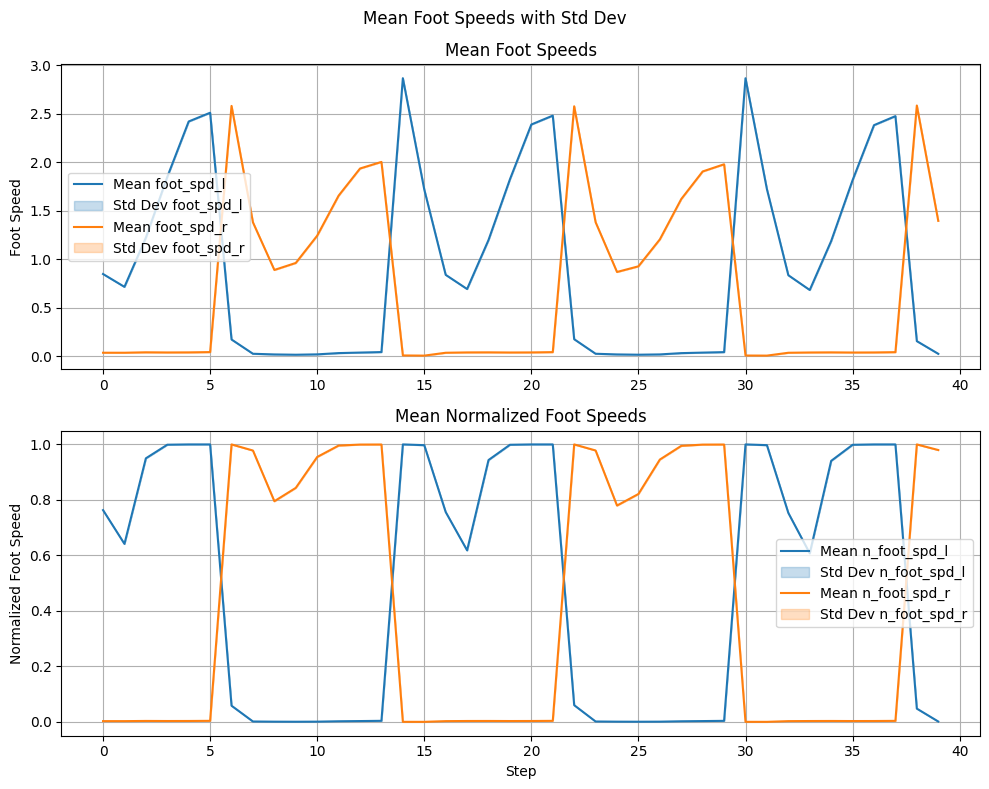

In [42]:
mean_foot_spd_l = np.nanmean(foot_spd_l.cpu().numpy(), axis=0)
mean_foot_spd_r = np.nanmean(foot_spd_r.cpu().numpy(), axis=0)
mean_foot_n_spd_l = np.nanmean(n_foot_spd_l.cpu().numpy(), axis=0)
mean_foot_n_spd_r = np.nanmean(n_foot_spd_r.cpu().numpy(), axis=0)

std_foot_spd_l = np.nanstd(foot_spd_l.cpu().numpy(), axis=0)
std_foot_spd_r = np.nanstd(foot_spd_r.cpu().numpy(), axis=0)
std_foot_n_spd_l = np.nanstd(n_foot_spd_l.cpu().numpy(), axis=0)
std_foot_n_spd_r = np.nanstd(n_foot_spd_r.cpu().numpy(), axis=0)

# ci95_foot_spd_l = 1.960 * std_foot_spd_l / np.sqrt(num_envs)
# ci95_foot_spd_r = 1.960 * std_foot_spd_r / np.sqrt(num_envs)
# ci95_foot_n_spd_l = 1.960 * std_foot_n_spd_l / np.sqrt(num_envs)
# ci95_foot_n_spd_r = 1.960 * std_foot_n_spd_r / np.sqrt(num_envs)

# 2 subplots: mean foot speeds and normalized mean foot speeds with std shading
#from step 50 to 90
mean_foot_spd_l = mean_foot_spd_l[50:90]
mean_foot_spd_r = mean_foot_spd_r[50:90]
mean_foot_n_spd_l = mean_foot_n_spd_l[50:90]
mean_foot_n_spd_r = mean_foot_n_spd_r[50:90]

std_foot_spd_l = std_foot_spd_l[50:90]
std_foot_spd_r = std_foot_spd_r[50:90]
std_foot_n_spd_l = std_foot_n_spd_l[50:90]
std_foot_n_spd_r = std_foot_n_spd_r[50:90]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Mean Foot Speeds with Std Dev")   
ax1.plot(mean_foot_spd_l, label="Mean foot_spd_l")
ax1.fill_between(np.arange(len(mean_foot_spd_l)), mean_foot_spd_l - std_foot_spd_l, mean_foot_spd_l + std_foot_spd_l, color="C0", alpha=0.25,
                 label="Std Dev foot_spd_l")
ax1.plot(mean_foot_spd_r, label="Mean foot_spd_r")
ax1.fill_between(np.arange(len(mean_foot_spd_r)), mean_foot_spd_r - std_foot_spd_r, mean_foot_spd_r + std_foot_spd_r, color="C1", alpha=0.25,
                 label="Std Dev foot_spd_r")
ax1.set_ylabel("Foot Speed")
ax1.legend()
ax1.grid(True)  
ax1.set_title("Mean Foot Speeds")
ax2.plot(mean_foot_n_spd_l, label="Mean n_foot_spd_l")
ax2.fill_between(np.arange(len(mean_foot_n_spd_l)), mean_foot_n_spd_l - std_foot_n_spd_l, mean_foot_n_spd_l + std_foot_n_spd_l, color="C0", alpha=0.25,     
                    label="Std Dev n_foot_spd_l")
ax2.plot(mean_foot_n_spd_r, label="Mean n_foot_spd_r")
ax2.fill_between(np.arange(len(mean_foot_n_spd_r)), mean_foot_n_spd_r - std_foot_n_spd_r, mean_foot_n_spd_r + std_foot_n_spd_r, color="C1", alpha=0.25,
                    label="Std Dev n_foot_spd_r")
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Foot Speed")
ax2.legend()
ax2.grid(True)
ax2.set_title("Mean Normalized Foot Speeds")  
plt.tight_layout()
plt.show()  

### FOOT FORCES VS VELOCITIES (NORMALIZED AND NOT)

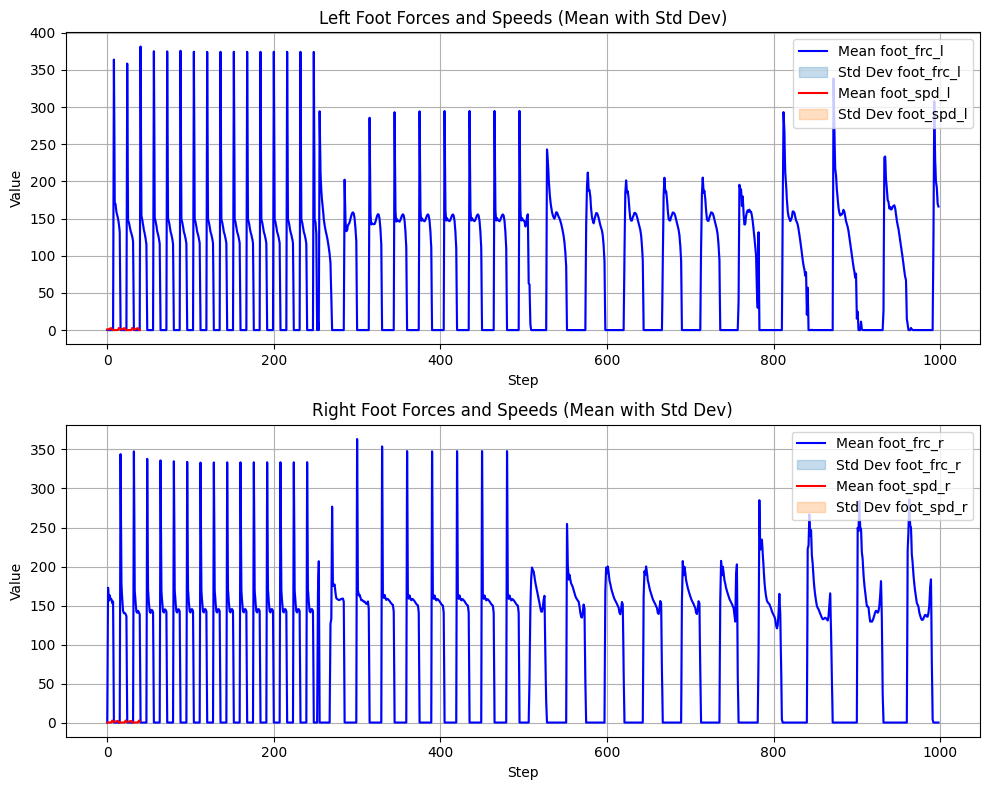

In [43]:
#2 subplots for left and right foot speed vs force with mean values and std shading
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(mean_foot_frc_l, label="Mean foot_frc_l", color='b')
axs[0].fill_between(np.arange(len(mean_foot_frc_l)), mean_foot_frc_l - std_foot_frc_l, mean_foot_frc_l + std_foot_frc_l, color="C0", alpha=0.25,
                 label="Std Dev foot_frc_l")
axs[0].plot(mean_foot_spd_l, label="Mean foot_spd_l", color='r')
axs[0].fill_between(np.arange(len(mean_foot_spd_l)), mean_foot_spd_l - std_foot_spd_l, mean_foot_spd_l + std_foot_spd_l, color="C1", alpha=0.25,
                 label="Std Dev foot_spd_l")
axs[0].set_title("Left Foot Forces and Speeds (Mean with Std Dev)")
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(mean_foot_frc_r, label="Mean foot_frc_r", color='b')
axs[1].fill_between(np.arange(len(mean_foot_frc_r)), mean_foot_frc_r - std_foot_frc_r, mean_foot_frc_r + std_foot_frc_r, color="C0", alpha=0.25,
                    label="Std Dev foot_frc_r") 
axs[1].plot(mean_foot_spd_r, label="Mean foot_spd_r", color='r')
axs[1].fill_between(np.arange(len(mean_foot_spd_r)), mean_foot_spd_r - std_foot_spd_r, mean_foot_spd_r + std_foot_spd_r, color="C1", alpha=0.25,
                    label="Std Dev foot_spd_r") 
axs[1].set_title("Right Foot Forces and Speeds (Mean with Std Dev)")
axs[1].set_xlabel("Step")       
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()  

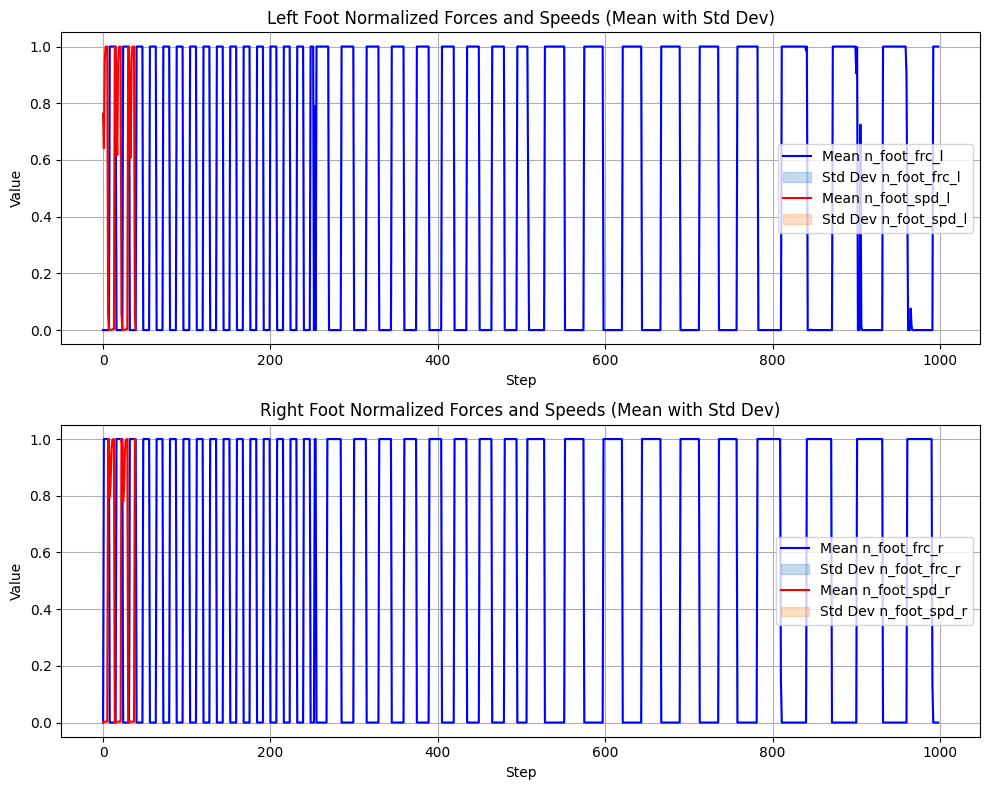

In [44]:
#2 subplots for left and right foot speed vs force with mean values and std shading (normalized)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(mean_foot_n_frc_l, label="Mean n_foot_frc_l", color='b')
axs[0].fill_between(np.arange(len(mean_foot_n_frc_l)), mean_foot_n_frc_l - std_foot_n_frc_l, mean_foot_n_frc_l + std_foot_n_frc_l, color="C0", alpha=0.25,
                 label="Std Dev n_foot_frc_l")
axs[0].plot(mean_foot_n_spd_l, label="Mean n_foot_spd_l", color='r')
axs[0].fill_between(np.arange(len(mean_foot_n_spd_l)), mean_foot_n_spd_l - std_foot_n_spd_l , mean_foot_n_spd_l + std_foot_n_spd_l, color="C1", alpha=0.25,
                 label="Std Dev n_foot_spd_l")
axs[0].set_title("Left Foot Normalized Forces and Speeds (Mean with Std Dev)")
axs[0].set_xlabel("Step")       
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(mean_foot_n_frc_r, label="Mean n_foot_frc_r", color='b')
axs[1].fill_between(np.arange(len(mean_foot_n_frc_r)), mean_foot_n_frc_r - std_foot_n_frc_r, mean_foot_n_frc_r + std_foot_n_frc_r, color="C0", alpha=0.25,
                    label="Std Dev n_foot_frc_r") 
axs[1].plot(mean_foot_n_spd_r, label="Mean n_foot_spd_r", color='r')
axs[1].fill_between(np.arange(len(mean_foot_n_spd_r)), mean_foot_n_spd_r - std_foot_n_spd_r, mean_foot_n_spd_r + std_foot_n_spd_r, color="C1", alpha=0.25,
                    label="Std Dev n_foot_spd_r") 
axs[1].set_title("Right Foot Normalized Forces and Speeds (Mean with Std Dev)")
axs[1].set_xlabel("Step")       
axs[1].set_ylabel("Value")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()


## **OBSERVATIONS**

### LINEAR POSITIONS OF THE PELVIS

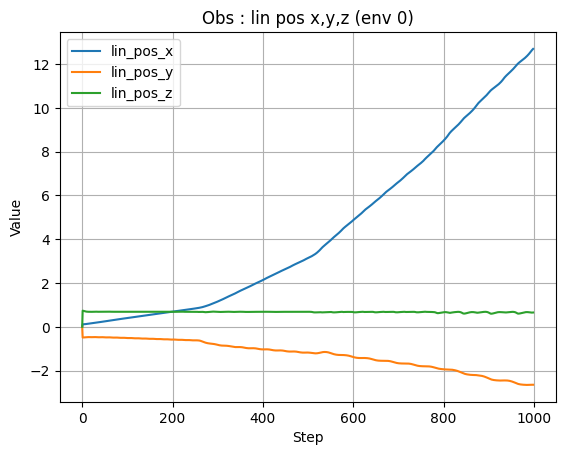

In [45]:

plt.plot(obs[env_id, :, -7:-4])
plt.legend(['lin_pos_x', 'lin_pos_y', 'lin_pos_z'])
plt.title(f"Obs : lin pos x,y,z (env {env_id})")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

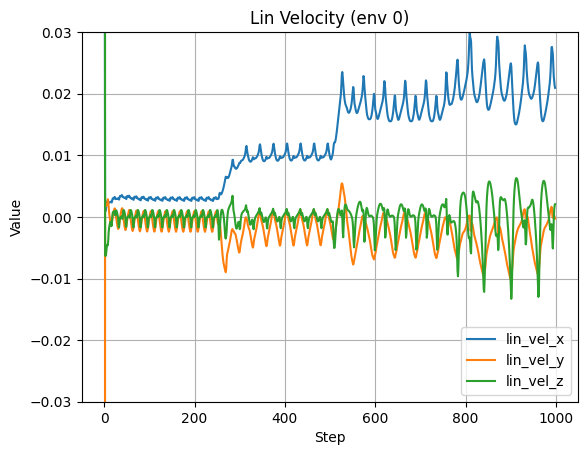

In [46]:
#compute and plot the derivative of the position (velocity)
lin_pos = obs[env_id, :, -7:-4].cpu().numpy()
lin_vel = np.gradient(lin_pos, axis=0)  # derivative along the time axis
plt.plot(lin_vel)
plt.legend(['lin_vel_x', 'lin_vel_y', 'lin_vel_z'])
plt.title(f"Lin Velocity (env {env_id})")
plt.xlabel("Step")
plt.ylabel("Value")
plt.ylim(-0.03, 0.03)
plt.grid(True)
plt.show()

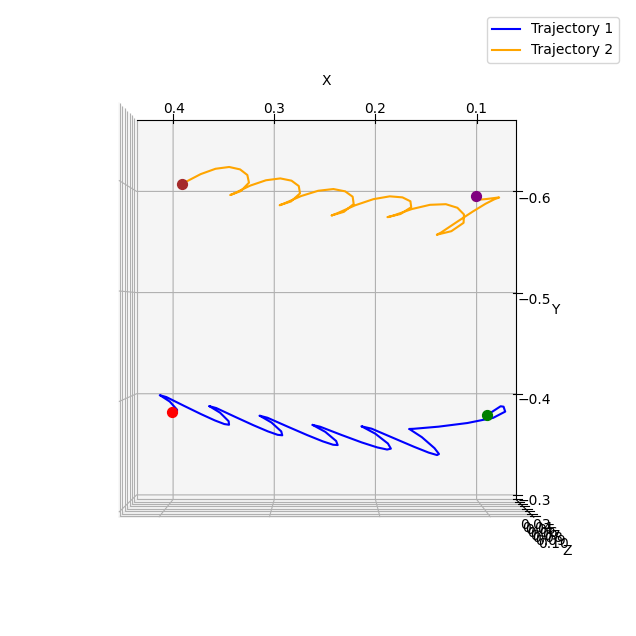

In [109]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator

# =========================
#  Tensori di esempio
# =========================
# Qui userai i tuoi veri tensori
trajectory1 = foot_pos_l[:,0:100,:].squeeze(0)   # shape (T1, 3)
trajectory2 = foot_pos_r[:,0:100,:].squeeze(0)   # shape (T2, 3)

# separo coordinate
x1, y1, z1 = trajectory1[:,0], trajectory1[:,1], trajectory1[:,2]
x2, y2, z2 = trajectory2[:,0], trajectory2[:,1], trajectory2[:,2]

# =========================
#   FIGURE PIÙ GRANDE
# =========================
fig = plt.figure(figsize=(12, 8))   # <--- aumenta la dimensione
ax = fig.add_subplot(111, projection='3d')

# =========================
#   PLOT DELLE 2 TRAIETTORIE
# =========================
ax.plot(x1, y1, z1, label='Trajectory 1', color='blue')
ax.plot(x2, y2, z2, label='Trajectory 2', color='orange')

# punti iniziali/finali opzionali
ax.scatter(x1[0], y1[0], z1[0], color='green', s=50)   # start traj1
ax.scatter(x1[-1], y1[-1], z1[-1], color='red', s=50)  # end traj1

ax.scatter(x2[0], y2[0], z2[0], color='purple', s=50)  # start traj2
ax.scatter(x2[-1], y2[-1], z2[-1], color='brown', s=50) # end traj2

# =========================
#   PUNTO DI VISTA (opzionale)
# =========================
ax.view_init(elev=90, azim=90)

x_tick_step = 0.1
ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))

# 2) Applica lo stesso passo a Y
ax.yaxis.set_major_locator(MultipleLocator(x_tick_step))


# Calcola i limiti attuali dopo aver plottato
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Trova il range massimo e centra entrambi gli assi sullo stesso range
max_range = max(x_max - x_min, y_max - y_min)
x_center = 0.5 * (x_max + x_min)
y_center = 0.5 * (y_max + y_min)

ax.set_xlim(x_center - max_range/2, x_center + max_range/2)
ax.set_ylim(y_center - max_range/2, y_center + max_range/2)



# labels + legenda
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

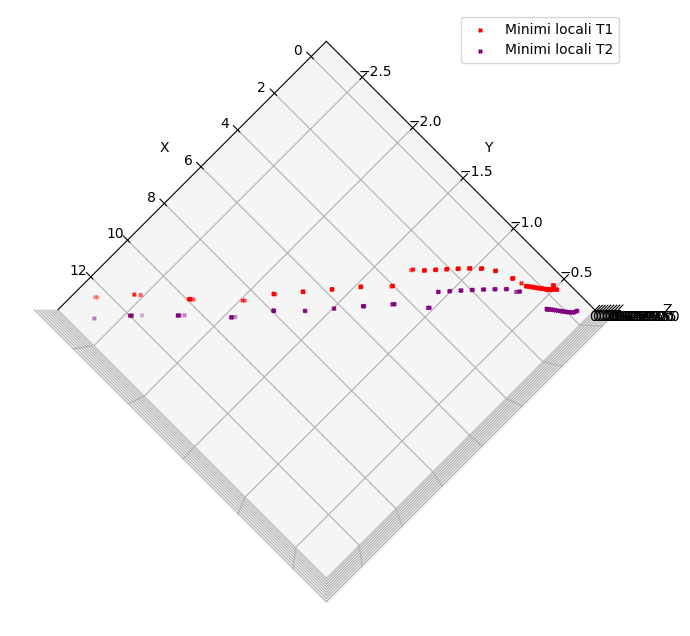

In [121]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------------------------
# Funzione per trovare i minimi locali su un vettore 1D
# -----------------------------------------------------
def local_minima_indices(x):
    # x è un tensore 1D (T,)
    return torch.where(
        (x[1:-1] < x[:-2]) & (x[1:-1] < x[2:]) & (x[1:-1]<0.05)
    )[0] + 1


# -----------------------------------------------------
# Carica le tue traiettorie (forma attesa: (1, T, 3))
# -----------------------------------------------------
traj1 = foot_pos_r.squeeze(0)   # (T1, 3)
traj2 = foot_pos_l.squeeze(0)   # (T2, 3)

# Estrai coordinate
x1, y1, z1 = traj1[:, 0], traj1[:, 1], traj1[:, 2]
x2, y2, z2 = traj2[:, 0], traj2[:, 1], traj2[:, 2]

# -----------------------------------------------------
# Trova i minimi locali su asse Z
# -----------------------------------------------------
min_idx1 = local_minima_indices(z1)
min_idx2 = local_minima_indices(z2)

# -----------------------------------------------------
# Plot 3D
# -----------------------------------------------------
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Traiettorie
# ax.plot(x1, y1, z1, label='Traiettoria 1', color='blue')
# ax.plot(x2, y2, z2, label='Traiettoria 2', color='orange')

# Minimi locali evidenziati
ax.scatter(x1[min_idx1], y1[min_idx1], z1[min_idx1],
           color='red', s=6, label='Minimi locali T1', marker='x')

ax.scatter(x2[min_idx2], y2[min_idx2], z2[min_idx2],
           color='purple', s=6, label='Minimi locali T2', marker='x')

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

# Punto di vista (personalizzabile)
ax.view_init(elev=90, azim=45)

plt.show()

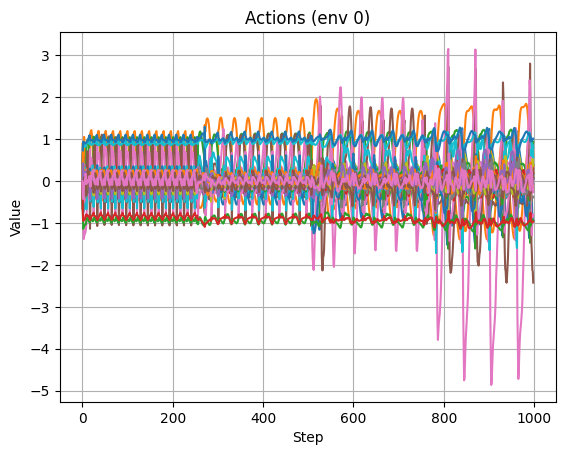

In [47]:

plt.plot(act[env_id, :, :])
plt.title(f"Actions (env {env_id})")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()
